1. Load and visualize MRI dataset
   * Load the MRI dataset containing images and masks
   * Open and display a random set of 10 images and corresponding masks from the dataset

2. Create a custom segmentation dataset from a set of images and masks?
   * Create a dictionary containing image and mask from the dataset
   * Split data into train and validation sets
   * Create train and validation data dictionaries with images and mask paths
   * Split train set by a fixed proportion to create test set
   * Display final dataset contents
   * Create an id2label mapping to convert from integers to actual class names

3. Implement data checks
   * Plot number of training and validation images within dataset
   * Load a sample image from train dataset
   * Display image, display image size, dtype, dimensions
   * Load corresponding ground truth mask
   * Display mask, display mask size, dtype, dimensions
   * Display label values in mask

4. Write a custom segmentation accuracy metric
   * Write a function to calculate mean IOU
   * The function takes in the ground truth and predicted masks
   * This function will be used in the next two milestones to estimate segmentation quality of trained models

5. Upload MRI dataset to Huggingface Hub
   * Create a Huggingface account and get your access token from user settings
   * Give your MRI dataset prepared in Step 2 a name to upload
   * Upload MRI dataset to Huggingface Hub

   

## Load MRI dataset, display images, implement data checks

In [ ]:
!pip install datasets==2.15.0

In [ ]:
!pip install huggingface-hub==0.19.0

In [3]:
# Import necessary libraries for data manipulation, image processing, and visualization
import numpy as np
import pandas as pd
import os

from matplotlib import pyplot as plt
import glob
import cv2

import seaborn as sns  # Import seaborn for statistical data visualization
from natsort import natsorted  # Import natsorted for natural sorting of file paths

# Import additional libraries for dataset loading and image processing
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset  # Import load_dataset and Dataset from datasets module
from PIL import Image  # Import the Image class from the Python Imaging Library (PIL)


In [4]:
## Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
## read images, display images +masks

# Define paths to the image and mask directories for training data
path_im = '/content/drive/MyDrive/colab_notebooks/lp2_files/mri_data_seg/images/train'
path_mask = '/content/drive/MyDrive/colab_notebooks/lp2_files/mri_data_seg/masks/train'

# Use glob to retrieve a list of file paths for images and masks
imfiles = glob.glob(path_im + '/*')
maskfiles = glob.glob(path_mask + '/*')


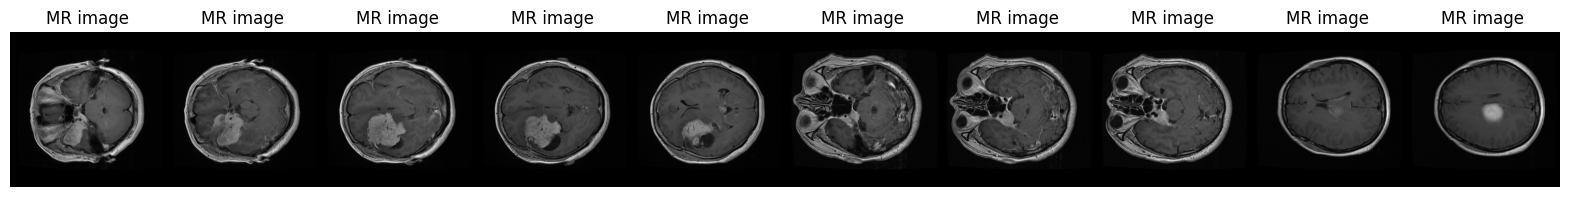

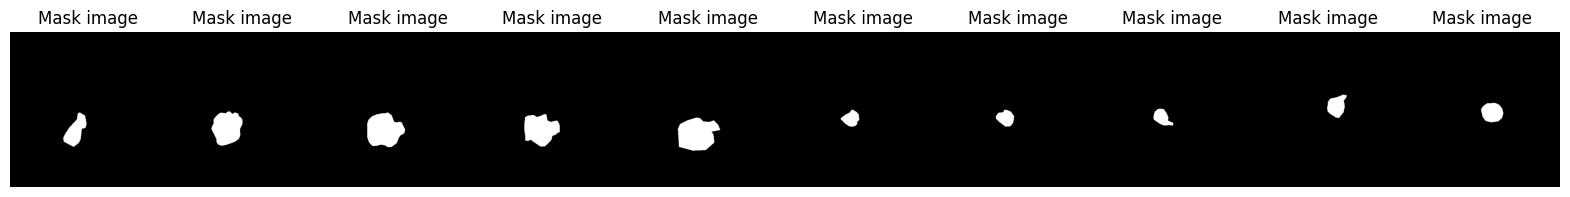

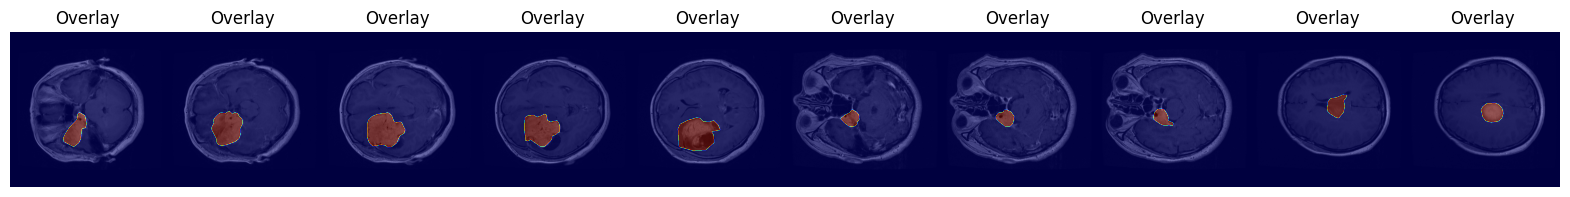

In [6]:
# Use natsorted to sort file paths in a human-readable order
imfiles = natsorted(glob.glob(path_im + '/*'))
maskfiles = natsorted(glob.glob(path_mask + '/*'))

# Visualize the first 10 MR images
plt.figure(figsize=(20, 20))
for i in range(len(imfiles[0:10])):
    plt.subplot(1, 10, i + 1)
    # Open and convert the image to RGB format
    image = Image.open(imfiles[i]).convert("RGB")

    plt.imshow(image)
    plt.axis('off')
    plt.title("MR image")
    plt.subplots_adjust(wspace=0, hspace=0)

plt.show()

# Visualize the first 10 mask images
plt.figure(figsize=(20, 20))
for i in range(len(maskfiles[0:10])):
    plt.subplot(2, 10, i + 1)
    # Open and convert the mask to grayscale format
    mask = Image.open(maskfiles[i]).convert("L")

    plt.imshow(mask, cmap="gray")
    plt.axis('off')
    plt.title("Mask image")
    plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

# Visualize the overlay of MR images and masks
plt.figure(figsize=(20, 20))
for i in range(len(maskfiles[0:10])):
    plt.subplot(2, 10, i + 1)
    # Open and convert the MR image and mask to RGB and grayscale formats, respectively
    image = Image.open(imfiles[i]).convert("RGB")
    mask = Image.open(maskfiles[i]).convert("L")
    plt.imshow(image, cmap='jet')
    plt.imshow(mask, cmap='jet', alpha=0.5)  # Overlay the mask on the MR image
    plt.axis('off')
    plt.title("Overlay")
    plt.subplots_adjust(wspace=0, hspace=0)
plt.show()


In [7]:
import os

# Lists to store file paths for training and validation images and masks
file_tr = []
mask_tr = []

file_val = []
mask_val = []

# Iterate through sorted files in the training images directory
for file1 in sorted(os.listdir('/content/drive/MyDrive/colab_notebooks/lp2_files/mri_data_seg/images/train')):
    file_tr.append('/content/drive/MyDrive/colab_notebooks/lp2_files/mri_data_seg/images/train/' + file1)

# Iterate through sorted files in the training masks directory
for file2 in sorted(os.listdir('/content/drive/MyDrive/colab_notebooks/lp2_files/mri_data_seg/masks/train')):
    mask_tr.append('/content/drive/MyDrive/colab_notebooks/lp2_files/mri_data_seg/masks/train/' + file2)

# Iterate through sorted files in the testing images directory
for file3 in sorted(os.listdir('/content/drive/MyDrive/colab_notebooks/lp2_files/mri_data_seg/images/test')):
    file_val.append('/content/drive/MyDrive/colab_notebooks/lp2_files/mri_data_seg/images/test/' + file3)

# Iterate through sorted files in the testing masks directory
for file4 in sorted(os.listdir('/content/drive/MyDrive/colab_notebooks/lp2_files/mri_data_seg/masks/test')):
    mask_val.append('/content/drive/MyDrive/colab_notebooks/lp2_files/mri_data_seg/masks/test/' + file4)


## Data check-1: Plot number of files in train and test dataset

Text(0, 0.5, 'Number of training and validation images')

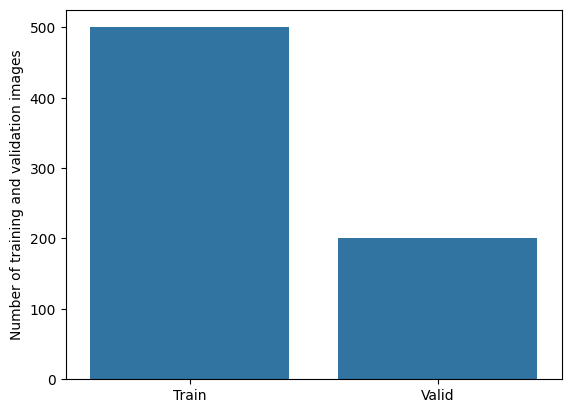

In [8]:
# Create a bar plot to visualize the number of training and validation images
fig = plt.figure()

# Add a subplot to the figure
ax = fig.add_subplot(111)

# Define x-axis labels and corresponding values for the bar plot
x = ['Train', 'Valid']
y = [len(file_tr), len(file_val)]

# Create a bar plot using seaborn
ax = sns.barplot(x=x, y=y)

# Set y-axis label
ax.set_ylabel('Number of training and validation images')


# Create a custom segmentation dataset from a set of images and masks?

In [ ]:
# Import necessary classes from the datasets module
from datasets import Dataset, DatasetDict, Image

# Define image and label paths for training data
image_paths_train = file_tr
label_paths_train = mask_tr

# Define image and label paths for validation data
image_paths_validation = file_val
label_paths_validation = mask_val



In [ ]:
# Define a function to create a dataset from image and label paths
def create_dataset(image_paths, label_paths):
    # Create a Dataset from a dictionary with keys "pixel_values" and "label"
    dataset = Dataset.from_dict({"pixel_values": sorted(image_paths),
                                 "label": sorted(label_paths)})

    # Cast the "pixel_values" and "label" columns to the Image data type
    dataset = dataset.cast_column("pixel_values", Image())
    dataset = dataset.cast_column("label", Image())

    return dataset

#  Create Dataset objects for training and validation
train_dataset = create_dataset(image_paths_train, label_paths_train)
validation_dataset = create_dataset(image_paths_validation, label_paths_validation)


In [ ]:
dataset = DatasetDict({
    "train": train_dataset,
    "validation": validation_dataset,
  }
)


In [ ]:
#Print dataset contents
dataset

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'label'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['pixel_values', 'label'],
        num_rows: 200
    })
})

In [ ]:
#Print training set contents
train_dataset

Dataset({
    features: ['pixel_values', 'label'],
    num_rows: 500
})

In [ ]:
# Split data into train, test and validation and rename parts properly
split_dataset = train_dataset.train_test_split(test_size=0.2)

split_dataset["val"] = split_dataset["test"]
split_dataset["test"] = validation_dataset

In [ ]:
#Display contents of split dataset
split_dataset

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'label'],
        num_rows: 400
    })
    test: Dataset({
        features: ['pixel_values', 'label'],
        num_rows: 200
    })
    val: Dataset({
        features: ['pixel_values', 'label'],
        num_rows: 100
    })
})

# Create an id2label mapping to convert from integers to actual class names

In [ ]:
id2label = {
    0:  'bg',
    1:  'tumor',

}
label2id = { label: id for id, label in id2label.items() }
n_classes = len(id2label)
## Display number of classes
print(n_classes)

2

## Data check-2:
* Load a sample image from train dataset
* Display image, display image size, dtype, dimensions
* Load corresponding ground truth mask
* Display mask, display mask size, dtype, dimensions
* Display label values in mask

Image/Mask dims (512, 512) (512, 512)
Image/Mask type uint8 uint8
Image min, max 0 255
Mask min, max 0 255
Labels in mask [  0 255]


Text(0.5, 1.0, 'Mask')

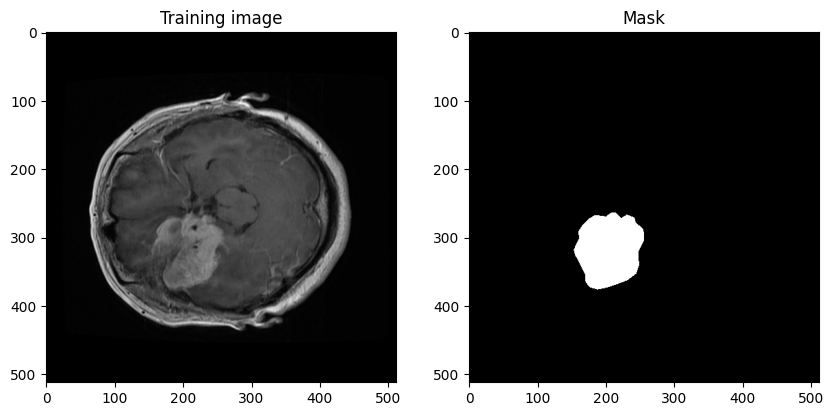

In [ ]:
# Get an example from the training dataset
example = train_dataset[1]

# Convert pixel values and label to NumPy arrays
im = np.array(example['pixel_values'])
mask = np.array(example['label'])

# Print dimensions, data types, and statistics of the image and mask
print("Image/Mask dims", im.shape, mask.shape)
print("Image/Mask type", im.dtype, mask.dtype)
print("Image min, max", im.min(), im.max())
print("Mask min, max", mask.min(), mask.max())
print("Labels in mask", np.unique(mask))

# Visualize the image and mask side by side
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(221)

# Display the training image
ax1.imshow(im, cmap='gray')
ax1.set_title('Training image')

ax2 = fig.add_subplot(222)

# Display the corresponding mask
ax2.imshow(mask, cmap='gray')
ax2.set_title('Mask')


# Write a custom function to calculate the mean IOU (intersection over union) segmentation accuracy metric

In [ ]:
# Define a function to calculate the mean Intersection over Union (IoU)

# y_true and y_pred are numpy arrays representing the ground truth and
# predicted segmentation masks, respectively, where each pixel value
# corresponds to the class label

def calculate_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    iou = np.sum(intersection) / np.sum(union)
    return iou

def calculate_mean_iou(y_true, y_pred):
    class_iou = []
    for i in range(1, np.max(y_true) + 1):
        y_true_i = (y_true == i)
        y_pred_i = (y_pred == i)
        class_iou.append(calculate_iou(y_true_i, y_pred_i))
    mean_iou = np.mean(class_iou)
    return mean_iou


In [ ]:
# Upload the MRI dataset on Huggingface Hub
from huggingface_hub import login
login(token='Your Token')
dataset.push_to_hub("MRI_Segmentation-1",private=True)

Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]